# Training a Classification Model on the German Traffic Sign Recognition Benchmark (GTSRB)

In [24]:
# --- Setup ---

# Pytorch
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import random_split
print("Using torch version " + str(torch.__version__))

# Others
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import os

Using torch version 2.10.0+cu128


In [25]:
# --- Settings ---

# General run settings
running_on_colab = False
gtsrb_data_pth = os.path.join(os.getcwd(), "data", "gtsrb", "GTSRB")
if running_on_colab:
    training_results_pth = os.path.join(os.getcwd(), "drive", "MyDrive", "Colab Notebooks")
    attack_data_pth = os.path.join(os.getcwd(), "drive", "MyDrive", "Computer Vision", "data")
else:
    training_results_pth = os.path.join(os.getcwd(), "model")
    attack_data_pth = os.path.join(os.getcwd(), "physical_adv_attack", "generated")

# Set which parts to run
run_first_model = True
run_adversarial_training = False

# Configure seeds
torch_seed = 1234
np.random.seed(1234)

# Model and training settings
num_classes = 43
batch_size = 64

# Configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [26]:
if running_on_colab:
    from google.colab import drive
    drive.mount('/content/drive')

Notes:
The training set archive is structures as follows:
One directory per class
Each directory contains one CSV file with annotations ("GT-<ClassID>.csv") and the training images
Training images are grouped by tracks
Each track contains 30 images of one single physical traffic sign

In [27]:
class GTSRBDataLoader:
    def __init__(self):
        # We need to resize images because -> "Image sizes vary between 15x15 to 250x250 pixels"
        # mean = (0.3403, 0.3121, 0.3214), std = (0.2724, 0.2608, 0.2673)
        self.transform = transforms.Compose([
            transforms.Resize((250, 250)), # For pretrained AlexNet we need at least 224x224
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.3403, 0.3121, 0.3214], std=[0.2724, 0.2608, 0.2669]) # Normalize according to: https://github.com/tomlawrenceuk/GTSRB-Dataloader
        ])

        self.test_data = None
        self.train_data = None

    def load_GTSRB_data(self):
        # TEST
        self.test_data = datasets.GTSRB( # 12630 samples
            root="data",
            split="test",
            download=True,
            transform=self.transform,
        )
        print(f"Test data loaded: {len(self.test_data)} samples")

        # TRAIN
        self.train_data = datasets.GTSRB( # 26640 samples
            root="data",
            split="train",
            download=True,
            transform=self.transform,
        )

        self.train_size = int(0.8 * len(self.train_data))
        self.val_size = len(self.train_data) - self.train_size
        self.train_subset, self.val_subset = random_split(self.train_data, [self.train_size, self.val_size], generator=torch.Generator().manual_seed(torch_seed))
        print(f"Train data loaded: {len(self.train_data)} samples")

        # EVAL
        #self.eval_data = datasets.GTSRB(
        #    root="data",
        #    split="eval",
        #    download=True,
        #    transform=self.transform,
        #)

# Instantiate
gtsrb_loader = GTSRBDataLoader()
gtsrb_loader.load_GTSRB_data()

Test data loaded: 12630 samples
Train data loaded: 26640 samples


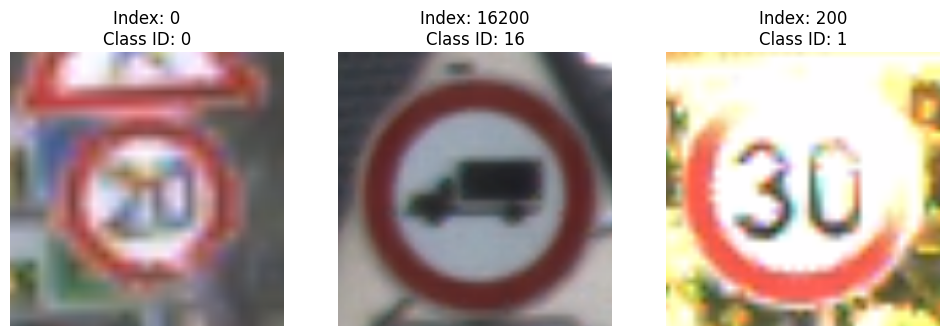

In [28]:
# To visualize images, we need to denormalize again
def visualize_images(dataset, indices):
    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        # Denormalize (Reverse: x * std + mean)
        # mean = (0.3403, 0.3121, 0.3214), std = (0.2724, 0.2608, 0.2669)
        img = image.numpy().transpose((1, 2, 0)) # Convert from (C, H, W) to (H, W, C)
        mean = np.array([0.3403, 0.3121, 0.3214])
        std = np.array([0.2724, 0.2608, 0.2673])
        img = std * img + mean
        img = np.clip(img, 0, 1) # Ensure values are within [0, 1]

        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Index: {idx}\nClass ID: {label}")
        plt.axis('off')
    plt.show()

# Important to know: "GTSRB is organized by "tracks"—sequences of images of the same physical sign as the car drives toward it."
# So consecutive datapoints/images often look very similar & have same classId.
visualize_images(gtsrb_loader.train_data, [0, 16200, 200])

# AlexNet Architecture

In [29]:
# We have 43 classes (need to recheck that though)
# Got most of this from: https://www.digitalocean.com/community/tutorials/alexnet-pytorch
class AlexNet(nn.Module):
        def __init__(self, num_classes=43):
            super(AlexNet, self).__init__()
            self.layer1 = nn.Sequential(
                nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0), # 3 input channels
                nn.BatchNorm2d(96),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.layer2 = nn.Sequential(
                nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
                nn.BatchNorm2d(256),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.layer3 = nn.Sequential(
                nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(384),
                nn.ReLU())
            self.layer4 = nn.Sequential(
                nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(384),
                nn.ReLU())
            self.layer5 = nn.Sequential(
                nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))

            # Flattened size is 256 * 5 * 5 = 6400
            # Fact check this I dont really understand the dimensions of linear layer yet.
            self.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(6400, 4096),
                nn.ReLU())
            self.fc1 = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(4096, 4096),
                nn.ReLU())
            self.fc2= nn.Sequential(
                nn.Linear(4096, num_classes))

        def forward(self, x):
            out = self.layer1(x)
            out = self.layer2(out)
            out = self.layer3(out)
            out = self.layer4(out)
            out = self.layer5(out)
            out = out.reshape(out.size(0), -1)
            out = self.fc(out)
            out = self.fc1(out)
            out = self.fc2(out)
            return out

In [30]:
model = AlexNet(num_classes).to(device)

# Hyperparameters

In [31]:
import pandas as pd

def training_loop(model, device, train_loader, valid_loader, training_fname, folder, num_epochs=20):
  # Loss and optimizer
  criterion = nn.CrossEntropyLoss()
  #optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9)
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


  training_df = pd.DataFrame(columns=["Epoch", "Loss", "Val Acc"])
  for epoch in range(num_epochs):
      # Training Phase
      model.train() # Set to train mode
      running_loss = 0.0

      train_bar = tqdm.tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train")

      for i, (images, labels) in enumerate(train_bar):
          images, labels = images.to(device), labels.to(device)

          outputs = model(images)
          loss = criterion(outputs, labels)

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          running_loss += loss.item()
          train_bar.set_postfix(loss=loss.item())

      # Validation Phase
      model.eval()
      correct = 0
      total = 0

      val_bar = tqdm.tqdm(valid_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Valid", leave=False)

      with torch.no_grad():
          for images, labels in val_bar:
              images, labels = images.to(device), labels.to(device)
              outputs = model(images)
              _, predicted = torch.max(outputs.data, 1)
              total += labels.size(0)
              correct += (predicted == labels).sum().item()

      accuracy = 100 * correct / total
      print(f'Done Epoch [{epoch+1}/{num_epochs}] | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {accuracy:.2f}%')

      training_df.loc[epoch] = [epoch, running_loss / len(train_loader), accuracy]
      training_df.to_csv(os.path.join(folder, training_fname + ".csv"), index=False)

      torch.save(model.state_dict(), os.path.join(folder, training_fname + ".pth"))

In [32]:
if run_first_model:
  train_loader = torch.utils.data.DataLoader(gtsrb_loader.train_subset, batch_size=batch_size, shuffle=True)
  valid_loader = torch.utils.data.DataLoader(gtsrb_loader.val_subset, batch_size=batch_size, shuffle=True)

  training_loop(model, device, train_loader, valid_loader, "first_model_weights", training_results_pth)

Epoch [1/20] Train: 100%|██████████| 333/333 [02:11<00:00,  2.52it/s, loss=0.268] 


Done Epoch [1/20] | Loss: 1.1557 | Val Acc: 92.34%


Epoch [2/20] Train: 100%|██████████| 333/333 [02:08<00:00,  2.58it/s, loss=0.035]  


Done Epoch [2/20] | Loss: 0.1029 | Val Acc: 98.86%


Epoch [3/20] Train: 100%|██████████| 333/333 [02:21<00:00,  2.35it/s, loss=0.0194] 


...

Done Epoch [18/20] | Loss: 0.0091 | Val Acc: 99.62%


Epoch [19/20] Train: 100%|██████████| 333/333 [02:15<00:00,  2.46it/s, loss=0.015]   


Done Epoch [19/20] | Loss: 0.0085 | Val Acc: 99.68%


Epoch [20/20] Train: 100%|██████████| 333/333 [02:21<00:00,  2.36it/s, loss=0.000133]


Done Epoch [20/20] | Loss: 0.0125 | Val Acc: 99.87%


# Evaluate

In [40]:
def test_model(model):
    model.eval() # set to eval mode

    test_loader = torch.utils.data.DataLoader(gtsrb_loader.test_data, batch_size=batch_size, shuffle=False)

    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in tqdm.tqdm(test_loader, desc="Testing"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_accuracy = 100 * test_correct / test_total
    print(f'\n===============================')
    print(f'Final Test Accuracy: {test_accuracy:.2f}%')
    print(f'===============================')

In [41]:
if run_first_model:
    test_model(model)

Testing: 100%|██████████| 198/198 [00:46<00:00,  4.26it/s]


Final Test Accuracy: 97.98%


# Adversarial Defences

## Adversarial Training

In [35]:
from torch.utils.data import Dataset
from PIL import Image

In [36]:
class ImageProperties():
  def __init__(self, fname, fclass, train=True):
    self.fname = fname
    self.fclass = fclass
    self.train = train

  def get_fpath_initial(self):
    if self.train:
      return os.path.join(gtsrb_data_pth, "Training", f"{self.fclass:05d}", self.fname + ".ppm")
    else:
      return os.path.join(gtsrb_data_pth, "Final_Test", "Images", self.fname + ".ppm")

  def get_fpath_attack(self, attack):
    # If runnning on Colab, use old filename structure
    prefix = f"{self.fclass:05d}_" if running_on_colab else ""

    return os.path.join(attack_data_pth, "train" if self.train else "test", attack, f"{self.fclass:02d}", f"{prefix}{self.fname}_{attack}_00.png")

  def get_fname(self):
    return self.fname

  def get_fclass(self):
    return self.fclass

In [37]:
# Reference: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files
class AdversarialTrainingDataset(Dataset):
    def __init__(self, transform, ratio, train_files: list[ImageProperties], attack_name="shadow"):
      self.transform = transform
      self.train_files = train_files
      self.attack_name = attack_name
      self.attack_dir = os.path.join(attack_data_pth, "train", self.attack_name)
      self.length = len(self.train_files)

      # Generate a random split between adversarial and non-adversarial data
      max_idx = int(self.length * ratio)
      self.non_adv_adv_split = np.full((self.length,), False)
      self.non_adv_adv_split[:max_idx] = True
      np.random.shuffle(self.non_adv_adv_split)

    def __len__(self):
      return self.length

    def __getitem__(self, idx):
      img_props = self.train_files[idx]
      img_path = img_props.get_fpath_initial() if self.non_adv_adv_split[idx] else img_props.get_fpath_attack(self.attack_name)
      img = Image.open(img_path)
      transformed_img = self.transform(img)
      return transformed_img, img_props.get_fclass()

In [38]:
def adversarial_training(ratio, attack_name="shadow"):
  # Build data structure to easily access training file properties
  train_files = []
  train_pth = os.path.join(gtsrb_data_pth, "Training")
  for folder in os.listdir(train_pth):
    if os.path.isfile(os.path.join(train_pth, folder)):
      continue

    for img in os.listdir(os.path.join(train_pth, folder)):
      if not ".ppm" in img:
        continue

      train_files.append(ImageProperties(img.split(".")[0], int(folder)))

  train_data = AdversarialTrainingDataset(gtsrb_loader.transform, ratio, train_files, attack_name)
  train_subset, val_subset = random_split(train_data, [gtsrb_loader.train_size, gtsrb_loader.val_size], generator=torch.Generator().manual_seed(torch_seed))

  train_loader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
  valid_loader = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=True)

  training_loop(model, device, train_loader, valid_loader, training_fname=f"adv_training_{ratio}_{attack_name}", folder=training_results_pth)

In [39]:
if run_adversarial_training:
  adversarial_training(0.5, "occlusion")